# Importing the dependencies

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

# Loading the mnist dataset from keras.datasets

In [3]:
(X_train, Y_train), (x_test, Y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
type(X_train)

numpy.ndarray

In [5]:
print(X_train.shape)
print(Y_train.shape)
print(x_test.shape)
print(Y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [6]:
print(X_train[20])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38
  190  25   0   0   0   0   0   0   0   0]
 [  0   0   0  13  25  10   0   0   0   0   0   0   0   0   0   0   0 112
  252 125   4   0   0   0   0   0   0   0]
 [  0   0   0 132 252 113   0   0   0   0   0   0   0   0   0   0   0  61
  252 252  36   0   0   0   0   0   0   0]
 [  0   0   0 132 252 240  79   0   0   0   0   0   0   0   0   0   0  84
  252 252  36   0   0   0   0   0   0   0]
 [  0   0   0 132 252 252 238  52   0   0   0   0   0   0   0   

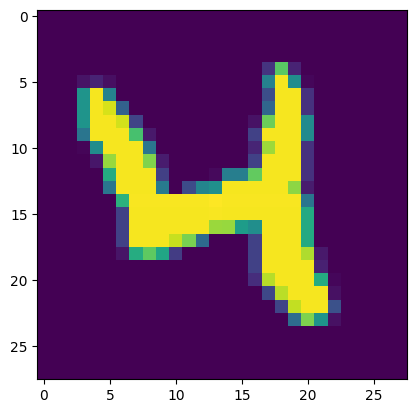

4


In [7]:
# display the image

plt.imshow(X_train[20])
plt.show()

# print the coreesponding label
print(Y_train[20])

we can use these labels as such or we can also apply one hot encoding

All the images have the same dimensions in this dataset. If not we have to resize all the images to a common dimension

In [8]:
# scaling the values
X_train = X_train/255
x_test = x_test/255

In [9]:
print(X_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

# Build The Neural Network

In [10]:
# setting up the layers of the Neural Network

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
# compile the nn

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
# training the NN

model.fit(X_train, Y_train, epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8539 - loss: 0.5076
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9542 - loss: 0.1509
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9676 - loss: 0.1079
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9749 - loss: 0.0854
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9800 - loss: 0.0690
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9821 - loss: 0.0581
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9845 - loss: 0.0498
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9874 - loss: 0.0421
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9891 - loss: 0.0366
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9899 - loss: 0.0322
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9905 - loss: 0.0295
Epoch 12/15
1875/1875 ━━━━━━━━

Training data accuracy = 99.21%

## Accuracy in test data

In [13]:
loss , accuracy = model.evaluate(x_test, Y_test)
print(f'Test accuracy = {accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9658 - loss: 0.1550
Test accuracy = 0.9695000052452087


In [14]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [15]:
print(y_pred.shape)

(10000, 10)


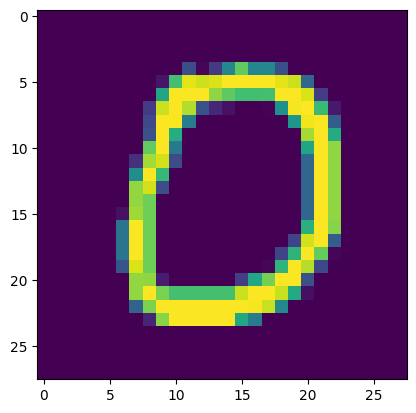

In [16]:
plt.imshow(x_test[10])
plt.show()

In [17]:
print(Y_test[10])

0


In [18]:
print(y_pred[10])

[1.00000000e+00 6.06507683e-12 1.22477919e-01 2.68369458e-05
 2.24594532e-06 1.95766613e-03 1.04439976e-04 3.30382423e-03
 1.00410307e-05 9.57551181e-01]


In [19]:
y_pred_labels = np.argmax(y_pred[10])
print(y_pred_labels)

0


In [21]:
# converting the prediction probablity to class level

y_pred_labels2 = [np.argmax(i) for i in y_pred]
print(y_pred_labels2)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

In [22]:
# confusion matrix

conf_mat = confusion_matrix(Y_test, y_pred_labels2).numpy()
print(conf_mat)

[[ 956    0    0    3    2    3    3    1    3    9]
 [   0 1115    0    6    3    1    2    1    5    2]
 [   2    0  990   11    4    2    3    5   14    1]
 [   1    0    1  997    1    1    0    2    3    4]
 [   0    1    4    0  967    1    0    2    3    4]
 [   2    0    0   35    1  841    3    0    5    5]
 [   3    3    2    2    2    6  930    0    7    3]
 [   2    1    4    3    3    0    0  980    9   26]
 [   0    1    4    8    3    6    0    2  946    4]
 [   0    1    0    7   18    3    0    4    3  973]]


Text(0.5, 47.7222222222222, 'Predicted Labels')

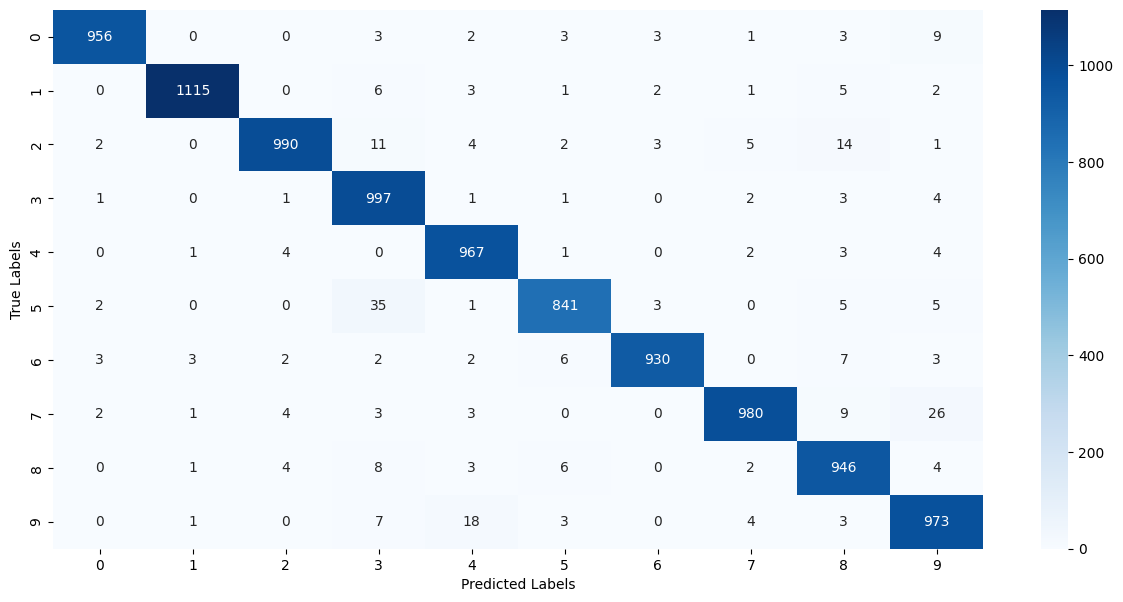

In [23]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

## Build a Predictive System

In [24]:
input_img_path = "/content/MNIST_digit.png"

input_img = cv2.imread(input_img_path)

In [25]:
type(input_img)

numpy.ndarray

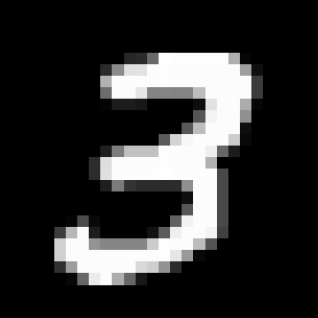

In [26]:
cv2_imshow(input_img)

In [27]:
input_img.shape

(318, 318, 3)

In [28]:
input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)

In [29]:
input_img_resize = cv2.resize(input_img, (28,28))

In [30]:
input_img_resize.shape

(28, 28)

In [31]:
cv2_imshow(input_img_resize)

In [32]:
input_img_resize = input_img_resize/255

In [33]:
from matplotlib import image
image_reshape = np.reshape(input_img_resize, [1,28,28])

In [34]:
prediction = model.predict(image_reshape)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[8.5470303e-12 1.0523996e-03 7.6964248e-08 1.0000000e+00 2.9052470e-20
  2.0777540e-02 1.1105386e-26 7.1259629e-04 5.0147128e-01 9.9990445e-01]]


In [35]:
predict = np.argmax(prediction)
print(predict)

3


Enter the path of the image to be predicted: /content/MNIST_digit.png


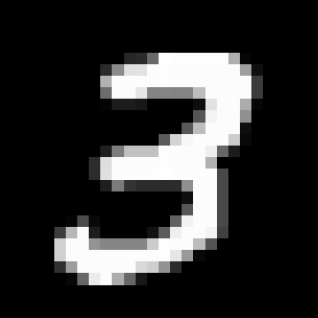

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
The number in the image is:  3


In [37]:
# predictive system

input_img_path = input("Enter the path of the image to be predicted: ")

input_img = cv2.imread(input_img_path)

cv2_imshow(input_img)

input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)

input_img_resize = cv2.resize(input_img, (28,28))

input_img_resize = input_img_resize/255

from matplotlib import image
image_reshape = np.reshape(input_img_resize, [1,28,28])

prediction = model.predict(image_reshape)

predict = np.argmax(prediction)

print("The number in the image is: ", predict)